In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Proj')

['Zomato Restaurant reviews.csv',
 'Zomato Restaurant names and Metadata.csv',
 'artifacts',
 'cache']

In [ ]:
import pandas as pd

REVIEWS_PATH  = "/content/drive/MyDrive/Proj/Zomato Restaurant reviews.csv"
METADATA_PATH = "/content/drive/MyDrive/Proj/Zomato Restaurant names and Metadata.csv"

df_rev  = pd.read_csv(REVIEWS_PATH)
df_meta = pd.read_csv(METADATA_PATH)

In [ ]:
df_rev.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [ ]:
df_meta.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [ ]:
# ======================================================
# CELL 1 — Install Required Packages
# ======================================================
# Restaurant Rating Prediction using ML + NLP + BERT + LightGBM
# Product-Quality Google Colab Setup
# ======================================================

print("Installing required packages...")

# Core ML
!pip -q install lightgbm
!pip -q install imbalanced-learn
!pip -q install shap

# NLP
!pip -q install sentence-transformers
!pip -q install transformers
!pip -q install accelerate
!pip -q install datasets

# Utilities
!pip -q install joblib
!pip -q install huggingface-hub

print("\n✅ All required packages installed successfully!")

# ======================================================
# Verify Installation
# ======================================================

import numpy as np
import pandas as pd
import sklearn
import lightgbm
import shap
import transformers
import sentence_transformers
import datasets
import joblib

print("\n========== Package Versions ==========")
print(f"NumPy                 : {np.__version__}")
print(f"Pandas                : {pd.__version__}")
print(f"Scikit-Learn          : {sklearn.__version__}")
print(f"LightGBM              : {lightgbm.__version__}")
print(f"SHAP                  : {shap.__version__}")
print(f"Transformers          : {transformers.__version__}")
print(f"SentenceTransformers  : {sentence_transformers.__version__}")
print(f"Datasets              : {datasets.__version__}")
print(f"Joblib                : {joblib.__version__}")

print("\n✅ Environment is ready.")

Installing required packages...

✅ All required packages installed successfully!

========== Package Versions ==========
NumPy                 : 2.0.2
Pandas                : 2.2.2
Scikit-Learn          : 1.6.1
LightGBM              : 4.6.0
SHAP                  : 0.52.0
Transformers          : 5.13.1
SentenceTransformers  : 5.6.0
Datasets              : 4.0.0
Joblib                : 1.5.3

✅ Environment is ready.


In [ ]:
# =====================================================
# CELL 2 — Imports
# =====================================================

# ----------------------------
# Standard Library
# ----------------------------
import os
import re
import json
import pickle
import warnings
from pathlib import Path

# ----------------------------
# Data Manipulation
# ----------------------------
import numpy as np
import pandas as pd

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Machine Learning
# ----------------------------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import PCA

# ----------------------------
# Metrics
# ----------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

# ----------------------------
# Imbalanced Learning
# ----------------------------
from imblearn.combine import SMOTETomek

# ----------------------------
# Model
# ----------------------------
import lightgbm as lgb

# ----------------------------
# Explainability
# ----------------------------
import shap

# ----------------------------
# Sparse Matrix
# ----------------------------
from scipy.sparse import hstack, csr_matrix

# ----------------------------
# Model Saving
# ----------------------------
import joblib

# =====================================================
# Global Settings
# =====================================================

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("✅ Imports completed successfully.")

✅ Imports completed successfully.


In [ ]:
# =====================================================
# CELL 3 — Google Drive Mount
# =====================================================

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
    DRIVE_ROOT = "/content/drive/MyDrive/Zomato_Rating_Prediction"
except Exception as e:
    print(f"Not running in Colab (or mount failed): {e}")
    IN_COLAB = False
    DRIVE_ROOT = "./Zomato_Rating_Prediction"

os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/cache", exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/artifacts", exist_ok=True)

print(f"📁 Project root: {DRIVE_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Project root: /content/drive/MyDrive/Zomato_Rating_Prediction


In [ ]:
# =====================================================
# CELL 4 — Load Dataset
# =====================================================

import os
import pandas as pd

# Correct DRIVE_ROOT for this cell to where the data files are located
DRIVE_ROOT = "/content/drive/MyDrive/Proj"

REVIEWS_PATH = os.path.join(DRIVE_ROOT, "Zomato Restaurant reviews.csv")
METADATA_PATH = os.path.join(DRIVE_ROOT, "Zomato Restaurant names and Metadata.csv")

# Verify files exist
assert os.path.exists(REVIEWS_PATH), f"Reviews file not found: {REVIEWS_PATH}"
assert os.path.exists(METADATA_PATH), f"Metadata file not found: {METADATA_PATH}"

# Load datasets
df_reviews = pd.read_csv(REVIEWS_PATH)
df_metadata = pd.read_csv(METADATA_PATH)

print(f"✅ Reviews Shape  : {df_reviews.shape}")
print(f"✅ Metadata Shape : {df_metadata.shape}")

display(df_reviews.head())
display(df_metadata.head())

✅ Reviews Shape  : (10000, 7)
✅ Metadata Shape : (105, 6)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [ ]:
# =====================================================
# CELL 5.1 — Schema & Missing-Value Audit
# =====================================================

print("=" * 70)
print("REVIEWS DATASET — INFO")
print("=" * 70)
df_reviews.info()

print("\n📌 Missing Values (Reviews)")
display(df_reviews.isnull().sum().to_frame("Missing_Count"))

print("\n📌 Duplicate Rows (Reviews):", df_reviews.duplicated().sum())

print("\n" + "=" * 70)
print("METADATA DATASET — INFO")
print("=" * 70)
df_metadata.info()

print("\n📌 Missing Values (Metadata)")
display(df_metadata.isnull().sum().to_frame("Missing_Count"))

print("\n📌 Duplicate Rows (Metadata):", df_metadata.duplicated().sum())

REVIEWS DATASET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB

📌 Missing Values (Reviews)


,Missing_Count
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0



📌 Duplicate Rows (Reviews): 36

METADATA DATASET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB

📌 Missing Values (Metadata)


,Missing_Count
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1



📌 Duplicate Rows (Metadata): 0


Raw Rating Distribution:


,Count
Rating,
1,1735
1.5,9
2,684
2.5,19
3,1193
3.5,47
4,2373
4.5,69
5,3832


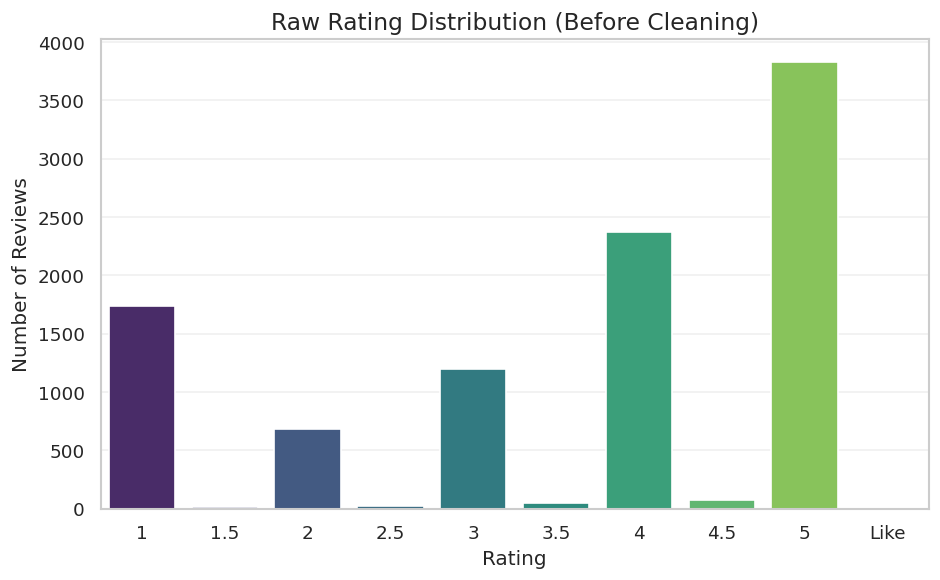

In [ ]:
# =====================================================
# CELL 5.2 — Raw Rating Distribution
# =====================================================

# Display raw rating counts (including missing values)
raw_rating_counts = df_reviews["Rating"].value_counts(dropna=False).sort_index()

print("Raw Rating Distribution:")
display(raw_rating_counts.to_frame("Count"))

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_reviews,
    x="Rating",
    order=sorted(df_reviews["Rating"].dropna().unique()),
    palette="viridis"
)

plt.title("Raw Rating Distribution (Before Cleaning)", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Cost Summary Statistics


,0
count,105.000000
mean,861.428571
std,510.149730
min,150.000000
25%,500.000000
50%,700.000000
75%,1200.000000
max,2800.000000


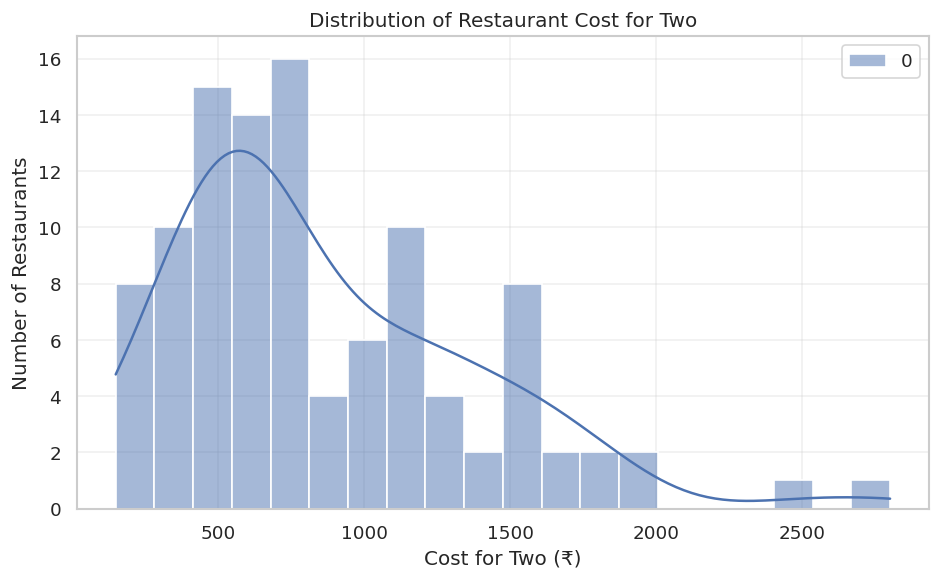

In [ ]:
# =====================================================
# CELL 5.3 — Restaurant Cost Distribution
# =====================================================

# Convert cost to numeric
cost_numeric = (
    df_metadata["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)")
    .astype(float)
)

print("Cost Summary Statistics")
display(cost_numeric.describe())

plt.figure(figsize=(8,5))

sns.histplot(
    cost_numeric,
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Restaurant Cost for Two")
plt.xlabel("Cost for Two (₹)")
plt.ylabel("Number of Restaurants")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
review_counts = df_reviews["Restaurant"].value_counts()

print(review_counts.describe())
print()
print("Unique review counts:", review_counts.nunique())
print()
print(review_counts.head(10))

count    100.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64

Unique review counts: 1

Restaurant
Beyond Flavours                   100
Paradise                          100
Flechazo                          100
Shah Ghouse Hotel & Restaurant    100
Over The Moon Brew Company        100
The Fisherman's Wharf             100
eat.fit                           100
Shah Ghouse Spl Shawarma          100
Hyper Local                       100
Cream Stone                       100
Name: count, dtype: int64


In [ ]:
print(review_counts.describe())
print(review_counts.nunique())
print(review_counts.head(10))

count    100.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64
1
Restaurant
Beyond Flavours                   100
Paradise                          100
Flechazo                          100
Shah Ghouse Hotel & Restaurant    100
Over The Moon Brew Company        100
The Fisherman's Wharf             100
eat.fit                           100
Shah Ghouse Spl Shawarma          100
Hyper Local                       100
Cream Stone                       100
Name: count, dtype: int64


📊 Review Count Statistics


,count
count,100.0
mean,100.0
std,0.0
min,100.0
25%,100.0
50%,100.0
75%,100.0
max,100.0


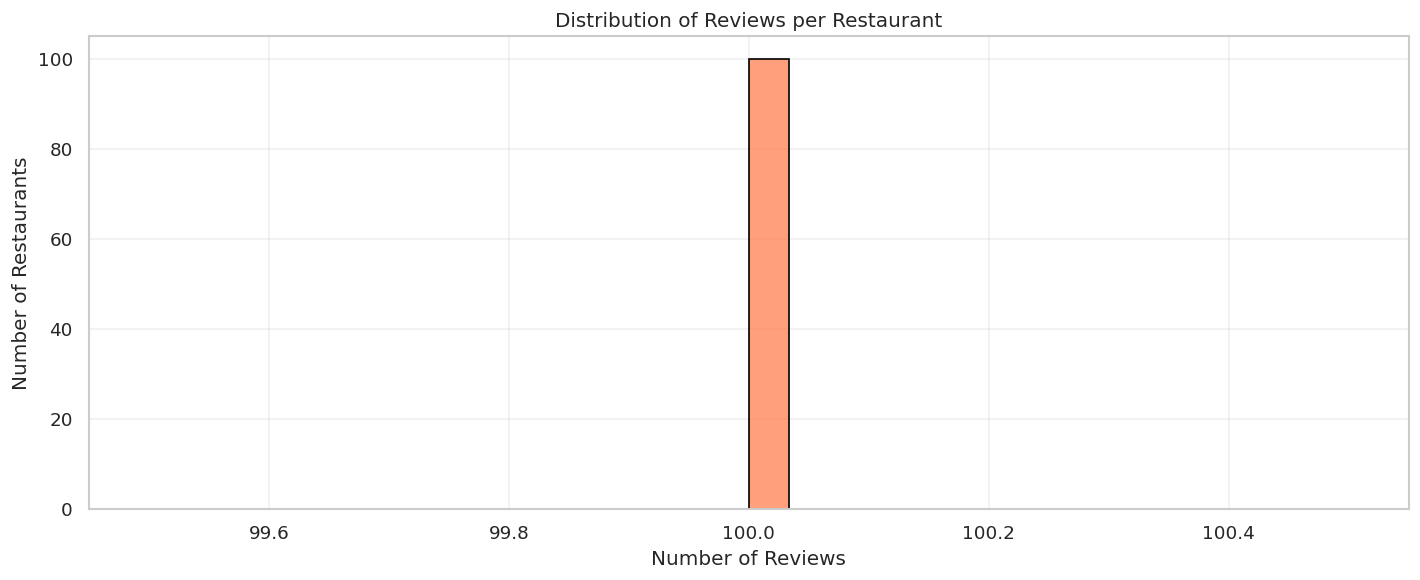

✅ Restaurant with most reviews : Beyond Flavours
✅ Maximum reviews              : 100
✅ Average reviews/restaurant   : 100.00
✅ Median reviews/restaurant    : 100.00


In [ ]:
# =====================================================
# CELL 5.4 — Reviews Per Restaurant
# =====================================================

review_counts = df_reviews["Restaurant"].value_counts()

print("📊 Review Count Statistics")
display(review_counts.describe())

plt.figure(figsize=(12,5))

sns.histplot(
    review_counts,
    bins=30,
    color="coral",
    edgecolor="black"
)

plt.title("Distribution of Reviews per Restaurant")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Restaurants")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Restaurant with most reviews : {review_counts.idxmax()}")
print(f"✅ Maximum reviews              : {review_counts.max()}")
print(f"✅ Average reviews/restaurant   : {review_counts.mean():.2f}")
print(f"✅ Median reviews/restaurant    : {review_counts.median():.2f}")

Top 10 Restaurants by Average Rating


,Average Rating
Restaurant,
AB's - Absolute Barbecues,4.88
B-Dubs,4.81
"3B's - Buddies, Bar & Barbecue",4.76
Paradise,4.70
Flechazo,4.66
The Indi Grill,4.60
Zega - Sheraton Hyderabad Hotel,4.45
Over The Moon Brew Company,4.34
Beyond Flavours,4.28


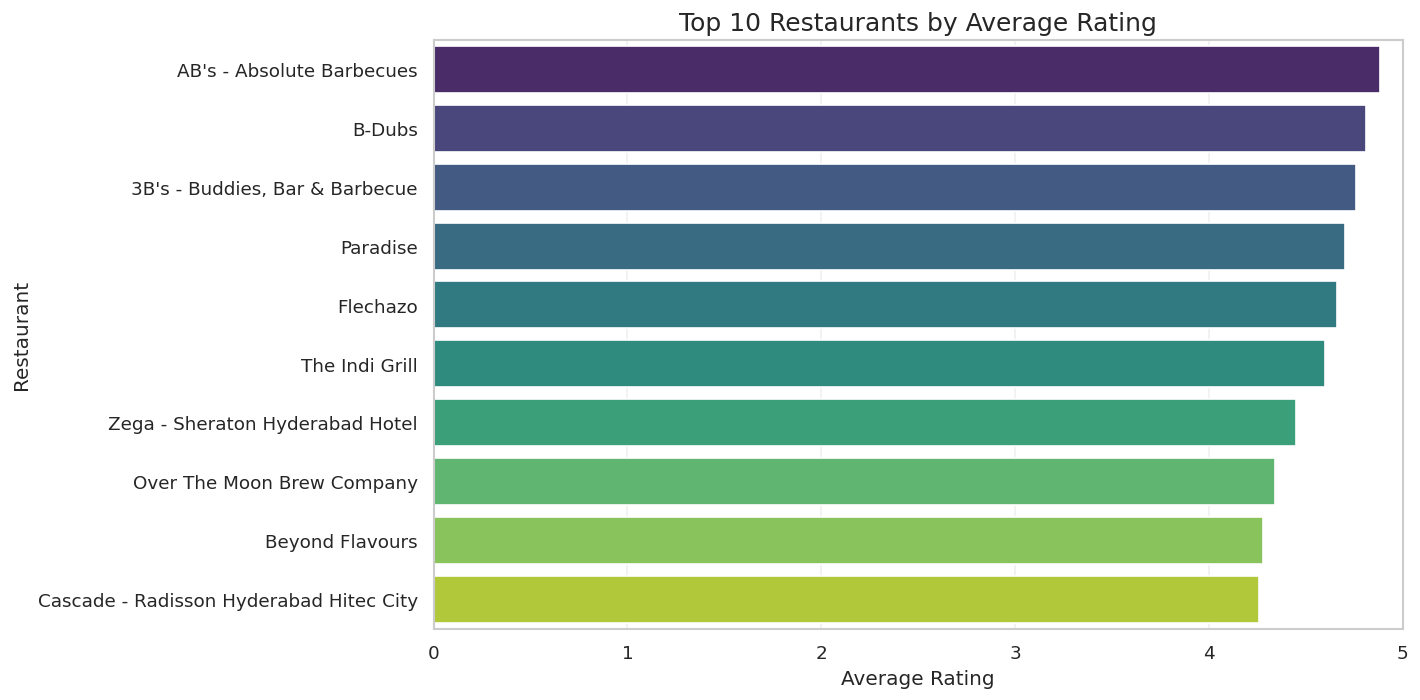

In [ ]:
# =====================================================
# CELL 5.4 — Restaurant Rating Summary (EDA)
# =====================================================

# Create a temporary copy for EDA only
eda_reviews = df_reviews.copy()

# Convert Rating to numeric (temporary)
eda_reviews["Rating"] = (
    eda_reviews["Rating"]
    .replace("Like", np.nan)
)

eda_reviews["Rating"] = pd.to_numeric(
    eda_reviews["Rating"],
    errors="coerce"
)

# Average rating per restaurant
restaurant_rating = (
    eda_reviews
    .groupby("Restaurant")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("="*60)
print("Top 10 Restaurants by Average Rating")
print("="*60)

display(
    restaurant_rating
    .head(10)
    .to_frame("Average Rating")
)

# Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=restaurant_rating.head(10).values,
    y=restaurant_rating.head(10).index,
    palette="viridis"
)

plt.title("Top 10 Restaurants by Average Rating", fontsize=15)
plt.xlabel("Average Rating")
plt.ylabel("Restaurant")

plt.xlim(0,5)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

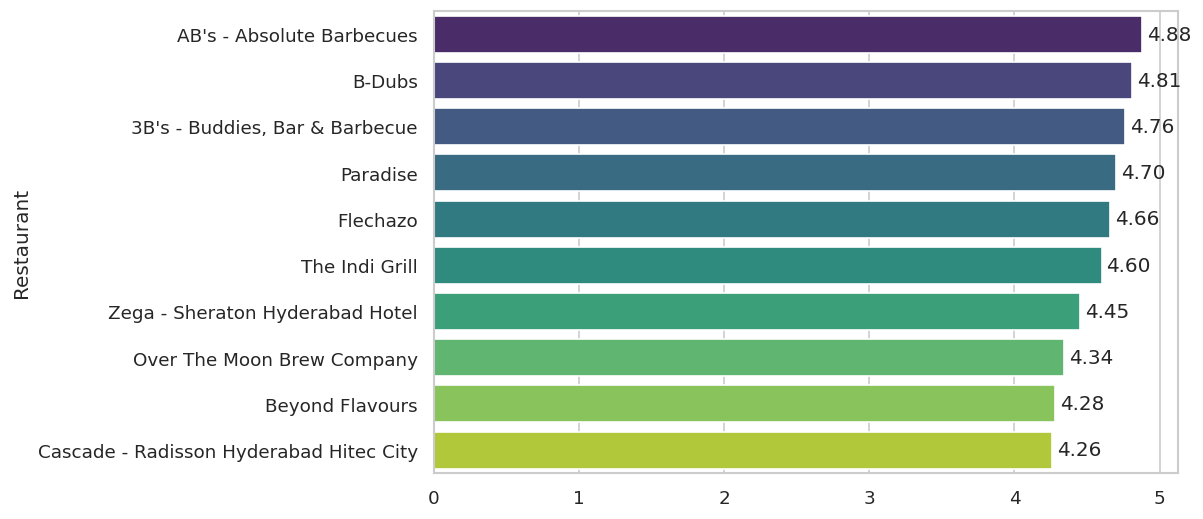

In [ ]:
ax = sns.barplot(
    x=restaurant_rating.head(10).values,
    y=restaurant_rating.head(10).index,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

In [ ]:
# =====================================================
# CELL 6 — Data Cleaning
# =====================================================

df_rev = df_reviews.copy()

# Remove invalid rating labels
df_rev["Rating"] = df_rev["Rating"].replace("Like", np.nan)

# Convert numeric columns
df_rev["Rating"] = pd.to_numeric(df_rev["Rating"], errors="coerce")
df_rev["Pictures"] = pd.to_numeric(df_rev["Pictures"], errors="coerce")

# Remove duplicate rows
before = len(df_rev)
df_rev = df_rev.drop_duplicates().reset_index(drop=True)
print(f"✅ Removed duplicate rows: {before-len(df_rev)}")

# Remove rows with missing target/review
before = len(df_rev)
df_rev = df_rev.dropna(subset=["Rating", "Review"]).reset_index(drop=True)
print(f"✅ Removed missing Rating/Review: {before-len(df_rev)}")

# Round ratings to nearest whole star (always round .5 up)
df_rev["Rating"] = np.floor(df_rev["Rating"] + 0.5).astype(int)

# Pictures
df_rev["Pictures"] = df_rev["Pictures"].fillna(0).astype(int)

# Review text
df_rev["Review"] = df_rev["Review"].astype(str).str.strip()

# Date
df_rev["Time"] = pd.to_datetime(
    df_rev["Time"].astype(str).str.split().str[0],
    errors="coerce"
)

# Metadata cleaning
df_meta = df_metadata.copy()

df_meta["Cost"] = pd.to_numeric(
    df_meta["Cost"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df_meta["Cuisines"] = df_meta["Cuisines"].fillna("Unknown")
df_meta["Collections"] = df_meta["Collections"].fillna("None")
df_meta["Timings"] = df_meta["Timings"].fillna("Not Specified")

# Merge
df = (
    df_rev.merge(
        df_meta[["Name", "Cost", "Cuisines", "Collections"]],
        left_on="Restaurant",
        right_on="Name",
        how="left"
    )
    .drop(columns=["Name"])
)

print("\n✅ Final Dataset Shape:", df.shape)

display(df.head())

✅ Removed duplicate rows: 36
✅ Removed missing Rating/Review: 10

✅ Final Dataset Shape: (9954, 10)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Cost,Cuisines,Collections
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",2019-05-25,0,800,"Chinese, Continental, Kebab, European, South I...","Food Hygiene Rated Restaurants in Hyderabad, C..."
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",2019-05-25,0,800,"Chinese, Continental, Kebab, European, South I...","Food Hygiene Rated Restaurants in Hyderabad, C..."
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",2019-05-24,0,800,"Chinese, Continental, Kebab, European, South I...","Food Hygiene Rated Restaurants in Hyderabad, C..."
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",2019-05-24,0,800,"Chinese, Continental, Kebab, European, South I...","Food Hygiene Rated Restaurants in Hyderabad, C..."
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",2019-05-24,0,800,"Chinese, Continental, Kebab, European, South I...","Food Hygiene Rated Restaurants in Hyderabad, C..."


In [ ]:
# =====================================================
# CELL 6.1 — Data Cleaning Validation
# =====================================================

print("=" * 60)
print("DATA CLEANING VALIDATION")
print("=" * 60)

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nRating Distribution")
display(df["Rating"].value_counts().sort_index())

print("\nData Types")
display(df.dtypes)

DATA CLEANING VALIDATION
Dataset Shape: (9954, 10)

Missing Values


,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Metadata,0
Time,0
Pictures,0
Cost,0
Cuisines,0
Collections,0



Duplicate Rows: 0

Rating Distribution


,count
Rating,
1,1735
2,693
3,1211
4,2420
5,3895



Data Types


,0
Restaurant,object
Reviewer,object
Review,object
Rating,int64
Metadata,object
Time,datetime64[ns]
Pictures,int64
Cost,int64
Cuisines,object
Collections,object


In [ ]:
print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)

print(f"Final Dataset Shape : {df.shape}")
print(f"Unique Restaurants  : {df['Restaurant'].nunique()}")
print(f"Unique Reviewers    : {df['Reviewer'].nunique()}")
print(f"Rating Classes      : {sorted(df['Rating'].unique())}")

print("\nRating Distribution")
display(df["Rating"].value_counts(normalize=True).sort_index().mul(100).round(2).to_frame("Percentage"))

DATA CLEANING SUMMARY
Final Dataset Shape : (9954, 10)
Unique Restaurants  : 100
Unique Reviewers    : 7442
Rating Classes      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rating Distribution


,Percentage
Rating,
1,17.43
2,6.96
3,12.17
4,24.31
5,39.13


In [ ]:
# =====================================================
# CELL 6.2 — Dataset Integrity Check
# =====================================================

print("=" * 60)
print("DATASET INTEGRITY CHECK")
print("=" * 60)

print(f"Rows                : {len(df):,}")
print(f"Columns             : {df.shape[1]}")
print(f"Memory Usage (MB)   : {df.memory_usage(deep=True).sum()/1024**2:.2f}")
print(f"Restaurants         : {df['Restaurant'].nunique()}")
print(f"Reviewers           : {df['Reviewer'].nunique()}")
print(f"Average Review Len  : {df['Review'].str.len().mean():.1f} characters")

print("\nRating Distribution (%)")
display(
    (
        df["Rating"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .to_frame("Percentage")
    )
)

DATASET INTEGRITY CHECK
Rows                : 9,954
Columns             : 10
Memory Usage (MB)   : 8.41
Restaurants         : 100
Reviewers           : 7442
Average Review Len  : 279.8 characters

Rating Distribution (%)


,Percentage
Rating,
1,17.43
2,6.96
3,12.17
4,24.31
5,39.13


In [ ]:
# =====================================================
# CELL 7 — Train / Test Split
# =====================================================

# Target variable
TARGET = "Rating"

# Stratified split to preserve class distribution
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Train Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")

print("\nTrain Rating Distribution (%)")
display(
    train_df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

print("\nTest Rating Distribution (%)")
display(
    test_df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

TRAIN / TEST SPLIT
Train Shape : (7963, 10)
Test Shape  : (1991, 10)

Train Rating Distribution (%)


,Percentage
Rating,
1,17.43
2,6.96
3,12.17
4,24.31
5,39.13



Test Rating Distribution (%)


,Percentage
Rating,
1,17.43
2,6.98
3,12.15
4,24.31
5,39.13


In [ ]:
# =====================================================
# CELL 8 — Feature Engineering (Row-wise Text Features)
# =====================================================

# This cell creates review-level features.
# These features depend ONLY on the current review,
# therefore they are completely leakage-free.

import re

# -----------------------------------------------------
# Positive & Negative Keyword Dictionaries
# -----------------------------------------------------

POS_WORDS = {
    "good", "great", "excellent", "amazing", "best",
    "love", "nice", "fantastic", "delicious",
    "wonderful", "awesome", "superb"
}

NEG_WORDS = {
    "bad", "worst", "terrible", "awful",
    "horrible", "poor", "disappointing",
    "slow", "rude", "cold", "stale",
    "overpriced"
}

# -----------------------------------------------------
# Helper Function
# -----------------------------------------------------

def count_keywords(text: str, keyword_set: set) -> int:
    """
    Count occurrences of keywords using whole-word matching.
    """
    if pd.isna(text):
        return 0

    words = re.findall(r"\b\w+\b", str(text).lower())

    return sum(word in keyword_set for word in words)


# -----------------------------------------------------
# Feature Engineering Function
# -----------------------------------------------------

def engineer_text_features(df_input: pd.DataFrame) -> pd.DataFrame:

    df_temp = df_input.copy()

    review_text = (
        df_temp["Review"]
        .fillna("")
        .astype(str)
    )

    # ------------------------------
    # Basic Length Features
    # ------------------------------

    df_temp["review_char_count"] = review_text.str.len()

    df_temp["review_word_count"] = review_text.str.split().str.len()

    df_temp["review_sentence_count"] = (
        review_text.str.count(r"[.!?]") + 1
    )

    df_temp["avg_word_length"] = (
        df_temp["review_char_count"] /
        df_temp["review_word_count"].clip(lower=1)
    )

    df_temp["log_word_count"] = np.log1p(
        df_temp["review_word_count"]
    )

    # ------------------------------
    # Punctuation Features
    # ------------------------------

    df_temp["exclamation_count"] = review_text.str.count("!")

    df_temp["question_count"] = review_text.str.count(r"\?")

    df_temp["uppercase_ratio"] = review_text.apply(
        lambda x: (
            sum(ch.isupper() for ch in x)
            / max(len(x), 1)
        )
    )

    # ------------------------------
    # Review Availability
    # ------------------------------

    df_temp["has_review"] = (
        ~review_text.str.strip().isin(["", "No Review"])
    ).astype(int)

    # ------------------------------
    # Keyword-based Sentiment Features
    # ------------------------------

    df_temp["positive_keyword_count"] = review_text.apply(
        lambda x: count_keywords(x, POS_WORDS)
    )

    df_temp["negative_keyword_count"] = review_text.apply(
        lambda x: count_keywords(x, NEG_WORDS)
    )

    df_temp["sentiment_score"] = (
        df_temp["positive_keyword_count"]
        - df_temp["negative_keyword_count"]
    )

    return df_temp


# =====================================================
# Apply Feature Engineering
# =====================================================

train_df = engineer_text_features(train_df)

test_df = engineer_text_features(test_df)

print("✅ Row-wise feature engineering completed.")

print("\nNew Features Added:")

new_features = [
    "review_char_count",
    "review_word_count",
    "review_sentence_count",
    "avg_word_length",
    "log_word_count",
    "has_review",
    "positive_keyword_count",
    "negative_keyword_count",
    "sentiment_score",
    "exclamation_count",
    "question_count",
    "uppercase_ratio",
]

display(train_df[new_features].head())

✅ Row-wise feature engineering completed.

New Features Added:


,review_char_count,review_word_count,review_sentence_count,avg_word_length,log_word_count,has_review,positive_keyword_count,negative_keyword_count,sentiment_score,exclamation_count,question_count,uppercase_ratio
0,286,43,22,6.651163,3.784190,1,0,1,-1,0,0,0.000000
1,297,56,6,5.303571,4.043051,1,3,0,3,0,0,0.016835
2,141,19,6,7.421053,2.995732,1,2,0,2,0,0,0.049645
3,97,20,1,4.850000,3.044522,1,1,0,1,0,0,0.000000
4,151,29,6,5.206897,3.401197,1,2,0,2,2,0,0.026490


In [ ]:
print(train_df[new_features].isnull().sum())
print(test_df[new_features].isnull().sum())

review_char_count         0
review_word_count         0
review_sentence_count     0
avg_word_length           0
log_word_count            0
has_review                0
positive_keyword_count    0
negative_keyword_count    0
sentiment_score           0
exclamation_count         0
question_count            0
uppercase_ratio           0
dtype: int64
review_char_count         0
review_word_count         0
review_sentence_count     0
avg_word_length           0
log_word_count            0
has_review                0
positive_keyword_count    0
negative_keyword_count    0
sentiment_score           0
exclamation_count         0
question_count            0
uppercase_ratio           0
dtype: int64


In [ ]:
# =====================================================
# CELL 9 — Leakage-Free Restaurant Aggregation
# =====================================================
# Creates restaurant-level features using ONLY the
# training data to avoid target leakage.
# =====================================================

from sklearn.model_selection import KFold
import joblib
import os

# -----------------------------------------------------
# Create Artifact Folder
# -----------------------------------------------------

ARTIFACT_DIR = os.path.join(DRIVE_ROOT, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------------------------------
# Global Defaults (Training Only)
# -----------------------------------------------------

GLOBAL_MEAN_RATING = train_df["Rating"].mean()

GLOBAL_REVIEW_COUNT = (
    train_df
    .groupby("Restaurant")
    .size()
    .median()
)

print(f"Global Mean Rating  : {GLOBAL_MEAN_RATING:.3f}")
print(f"Median Review Count : {GLOBAL_REVIEW_COUNT:.0f}")

# =====================================================
# K-Fold Target Encoding
# =====================================================

def kfold_target_encode(
    data,
    group_col,
    target_col,
    n_splits=5,
    random_state=RANDOM_STATE,
):

    encoded = pd.Series(index=data.index, dtype=float)

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for train_idx, valid_idx in kf.split(data):

        train_fold = data.iloc[train_idx]

        mapping = (
            train_fold
            .groupby(group_col)[target_col]
            .mean()
        )

        encoded.iloc[valid_idx] = (
            data.iloc[valid_idx][group_col]
            .map(mapping)
        )

    return encoded.fillna(data[target_col].mean())


# =====================================================
# K-Fold Count Encoding
# =====================================================

def kfold_count_encode(
    data,
    group_col,
    n_splits=5,
    random_state=RANDOM_STATE,
):

    encoded = pd.Series(index=data.index, dtype=float)

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for train_idx, valid_idx in kf.split(data):

        train_fold = data.iloc[train_idx]

        mapping = (
            train_fold
            .groupby(group_col)
            .size()
        )

        encoded.iloc[valid_idx] = (
            data.iloc[valid_idx][group_col]
            .map(mapping)
        )

    return encoded.fillna(GLOBAL_REVIEW_COUNT)


# =====================================================
# TRAIN FEATURES
# =====================================================

train_df["rest_avg_rating"] = kfold_target_encode(
    train_df,
    "Restaurant",
    "Rating"
)

train_df["rest_review_count"] = kfold_count_encode(
    train_df,
    "Restaurant"
)

train_df["restaurant_score"] = (
    (train_df["rest_avg_rating"] / 5.0)
    * np.log1p(train_df["rest_review_count"])
)

# =====================================================
# BUILD LOOKUP TABLE (TRAIN ONLY)
# =====================================================

train_rest_avg = (
    train_df
    .groupby("Restaurant")["Rating"]
    .mean()
)

train_rest_count = (
    train_df
    .groupby("Restaurant")
    .size()
)

restaurant_lookup = pd.DataFrame({
    "Restaurant": train_rest_avg.index,
    "rest_avg_rating": train_rest_avg.values,
    "rest_review_count": train_rest_count.values,
})

# =====================================================
# APPLY TO TEST SET
# =====================================================

test_df["rest_avg_rating"] = (
    test_df["Restaurant"]
    .map(train_rest_avg)
    .fillna(GLOBAL_MEAN_RATING)
)

test_df["rest_review_count"] = (
    test_df["Restaurant"]
    .map(train_rest_count)
    .fillna(GLOBAL_REVIEW_COUNT)
)

test_df["restaurant_score"] = (
    (test_df["rest_avg_rating"] / 5.0)
    * np.log1p(test_df["rest_review_count"])
)

# =====================================================
# VALIDATION
# =====================================================

print("\n" + "=" * 60)
print("RESTAURANT FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"Train Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")

unseen = (
    ~test_df["Restaurant"]
    .isin(train_rest_avg.index)
).sum()

print(f"Unseen Restaurants in Test : {unseen}")

print("\nRestaurant Feature Summary")
display(
    train_df[
        [
            "rest_avg_rating",
            "rest_review_count",
            "restaurant_score",
        ]
    ].describe()
)

print("\nSample Engineered Features")
display(
    train_df[
        [
            "Restaurant",
            "rest_avg_rating",
            "rest_review_count",
            "restaurant_score",
        ]
    ].head()
)

# =====================================================
# SAVE LOOKUP TABLE
# =====================================================

LOOKUP_PATH = os.path.join(
    ARTIFACT_DIR,
    "restaurant_lookup.pkl"
)

joblib.dump(
    restaurant_lookup,
    LOOKUP_PATH
)

print(f"\n✅ Restaurant lookup saved to:")
print(LOOKUP_PATH)

print("\n✅ Leakage-free restaurant feature engineering completed successfully.")

Global Mean Rating  : 3.608
Median Review Count : 80

RESTAURANT FEATURE ENGINEERING SUMMARY
Train Shape : (7963, 25)
Test Shape  : (1991, 25)
Unseen Restaurants in Test : 0

Restaurant Feature Summary


,rest_avg_rating,rest_review_count,restaurant_score
count,7963.000000,7963.000000,7963.000000
mean,3.606512,63.093809,2.999066
std,0.522970,4.937781,0.440703
min,2.254237,43.000000,1.845925
25%,3.228070,60.000000,2.664794
50%,3.617647,63.000000,3.007114
75%,3.911765,67.000000,3.253598
max,4.947368,78.000000,4.115502



Sample Engineered Features


,Restaurant,rest_avg_rating,rest_review_count,restaurant_score
0,KFC,3.107692,65.0,2.604032
1,Driven Cafe,3.769231,65.0,3.158355
2,American Wild Wings,4.093023,43.0,3.097755
3,Squeeze @ The Lime,3.914286,70.0,3.337069
4,B-Dubs,4.872727,55.0,3.922888



✅ Restaurant lookup saved to:
/content/drive/MyDrive/Proj/artifacts/restaurant_lookup.pkl

✅ Leakage-free restaurant feature engineering completed successfully.


In [ ]:
# =====================================================
# CELL 10 — Missing Value Imputation
# =====================================================
# Fit imputers ONLY on the training data
# and apply the learned statistics to both
# training and test datasets.
# =====================================================

from sklearn.impute import SimpleImputer
import joblib
import os

# -----------------------------------------------------
# Numeric Features
# -----------------------------------------------------

NUMERIC_IMPUTE_COLS = [
    "Cost",
    "Pictures"
]

numeric_imputer = SimpleImputer(strategy="median")

train_df[NUMERIC_IMPUTE_COLS] = numeric_imputer.fit_transform(
    train_df[NUMERIC_IMPUTE_COLS]
)

test_df[NUMERIC_IMPUTE_COLS] = numeric_imputer.transform(
    test_df[NUMERIC_IMPUTE_COLS]
)

# -----------------------------------------------------
# Validation
# -----------------------------------------------------

print("=" * 60)
print("NUMERIC IMPUTATION SUMMARY")
print("=" * 60)

print("\nLearned Statistics (Training Only)")

for col, value in zip(NUMERIC_IMPUTE_COLS, numeric_imputer.statistics_):
    print(f"{col:12s} : {value}")

print("\nMissing Values After Imputation")

print("\nTrain")
display(train_df[NUMERIC_IMPUTE_COLS].isnull().sum().to_frame("Missing"))

print("\nTest")
display(test_df[NUMERIC_IMPUTE_COLS].isnull().sum().to_frame("Missing"))

# -----------------------------------------------------
# Save Imputer
# -----------------------------------------------------

IMPUTER_PATH = os.path.join(
    ARTIFACT_DIR,
    "numeric_imputer.pkl"
)

joblib.dump(
    numeric_imputer,
    IMPUTER_PATH
)

print(f"\n✅ Numeric imputer saved to:\n{IMPUTER_PATH}")

print("\n✅ Numeric imputation completed successfully.")

NUMERIC IMPUTATION SUMMARY

Learned Statistics (Training Only)
Cost         : 700.0
Pictures     : 0.0

Missing Values After Imputation

Train


,Missing
Cost,0
Pictures,0



Test


,Missing
Cost,0
Pictures,0



✅ Numeric imputer saved to:
/content/drive/MyDrive/Proj/artifacts/numeric_imputer.pkl

✅ Numeric imputation completed successfully.


In [ ]:
# =====================================================
# CELL 11 — Safe Encoding
# =====================================================
# Fit encoders ONLY on training data.
# Unknown categories in the test set are mapped to -1.
# =====================================================

import joblib
import os

# -----------------------------------------------------
# Helper Function
# -----------------------------------------------------

def fit_safe_encoder(train_series):
    unique_values = sorted(train_series.astype(str).unique())
    mapping = {value: idx for idx, value in enumerate(unique_values)}
    return mapping

def transform_safe_encoder(series, mapping):
    return (
        series.astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

# -----------------------------------------------------
# Restaurant Encoding
# -----------------------------------------------------

restaurant_mapping = fit_safe_encoder(train_df["Restaurant"])

train_df["restaurant_id"] = transform_safe_encoder(
    train_df["Restaurant"],
    restaurant_mapping
)

test_df["restaurant_id"] = transform_safe_encoder(
    test_df["Restaurant"],
    restaurant_mapping
)

# -----------------------------------------------------
# Reviewer Encoding
# -----------------------------------------------------

reviewer_mapping = fit_safe_encoder(train_df["Reviewer"])

train_df["reviewer_id"] = transform_safe_encoder(
    train_df["Reviewer"],
    reviewer_mapping
)

test_df["reviewer_id"] = transform_safe_encoder(
    test_df["Reviewer"],
    reviewer_mapping
)

# -----------------------------------------------------
# Validation
# -----------------------------------------------------

print("=" * 60)
print("ENCODING SUMMARY")
print("=" * 60)

print(f"Restaurants Encoded : {len(restaurant_mapping)}")
print(f"Reviewers Encoded   : {len(reviewer_mapping)}")

print(f"\nUnknown Restaurants in Test : {(test_df['restaurant_id'] == -1).sum()}")
print(f"Unknown Reviewers in Test   : {(test_df['reviewer_id'] == -1).sum()}")

# -----------------------------------------------------
# Save Encoders
# -----------------------------------------------------

joblib.dump(
    restaurant_mapping,
    os.path.join(ARTIFACT_DIR, "restaurant_encoder.pkl")
)

joblib.dump(
    reviewer_mapping,
    os.path.join(ARTIFACT_DIR, "reviewer_encoder.pkl")
)

print("\n✅ Encoders saved successfully.")

display(
    train_df[
        [
            "Restaurant",
            "restaurant_id",
            "Reviewer",
            "reviewer_id"
        ]
    ].head()
)

ENCODING SUMMARY
Restaurants Encoded : 100
Reviewers Encoded   : 6192

Unknown Restaurants in Test : 0
Unknown Reviewers in Test   : 1300

✅ Encoders saved successfully.


,Restaurant,restaurant_id,Reviewer,reviewer_id
0,KFC,47,BABA RIYAZ SHAIK,908
1,Driven Cafe,30,Karan Dadure,2110
2,American Wild Wings,6,Chandra Sekhar,1126
3,Squeeze @ The Lime,79,Chinnu Chanti,1168
4,B-Dubs,11,Mallik Katthera,2524


In [ ]:
# =====================================================
# CELL 12 — TF-IDF Vectorization
# =====================================================
# Learn TF-IDF vocabulary ONLY from the training reviews.
# Apply the learned vocabulary to both training and test
# datasets to avoid data leakage.
# =====================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import os

# -----------------------------------------------------
# TF-IDF Configuration
# -----------------------------------------------------

tfidf_vectorizer = TfidfVectorizer(

    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    stop_words="english",
    strip_accents="unicode",
    sublinear_tf=True

)

# -----------------------------------------------------
# Fit ONLY on Training Reviews
# -----------------------------------------------------

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["Review"]
)

# -----------------------------------------------------
# Transform Test Reviews
# -----------------------------------------------------

X_test_tfidf = tfidf_vectorizer.transform(
    test_df["Review"]
)

# -----------------------------------------------------
# Validation
# -----------------------------------------------------

print("=" * 60)
print("TF-IDF SUMMARY")
print("=" * 60)

print(f"Training Matrix Shape : {X_train_tfidf.shape}")
print(f"Test Matrix Shape     : {X_test_tfidf.shape}")

print(f"\nVocabulary Size : {len(tfidf_vectorizer.vocabulary_):,}")

print(f"Maximum Features : {tfidf_vectorizer.max_features}")

print(f"Non-zero Entries (Train): {X_train_tfidf.nnz:,}")

print(f"Density (Train): "
      f"{100 * X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}%")

# -----------------------------------------------------
# Save Vectorizer
# -----------------------------------------------------

TFIDF_PATH = os.path.join(
    ARTIFACT_DIR,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    tfidf_vectorizer,
    TFIDF_PATH
)

print(f"\n✅ TF-IDF Vectorizer saved to:")
print(TFIDF_PATH)

print("\n✅ TF-IDF vectorization completed successfully.")

TF-IDF SUMMARY
Training Matrix Shape : (7963, 5000)
Test Matrix Shape     : (1991, 5000)

Vocabulary Size : 5,000
Maximum Features : 5000
Non-zero Entries (Train): 194,536
Density (Train): 0.4886%

✅ TF-IDF Vectorizer saved to:
/content/drive/MyDrive/Proj/artifacts/tfidf_vectorizer.pkl

✅ TF-IDF vectorization completed successfully.


In [ ]:
# =====================================================
# CELL 13 — BERT Sentence Embeddings
# =====================================================
# Generate dense sentence embeddings for review text.
#
# • Fit nothing (pretrained model)
# • No data leakage
# • Cache embeddings in Google Drive
# • GPU compatible
# =====================================================

from sentence_transformers import SentenceTransformer
import torch
import numpy as np
import os
import joblib

# -----------------------------------------------------
# Device
# -----------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("BERT EMBEDDING SETUP")
print("=" * 60)
print(f"Device : {DEVICE}")

# -----------------------------------------------------
# Model
# -----------------------------------------------------

BERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

print(f"Embedding Model : {BERT_MODEL_NAME}")

# -----------------------------------------------------
# Cache Directory
# -----------------------------------------------------

CACHE_DIR = os.path.join(DRIVE_ROOT, "cache")
os.makedirs(CACHE_DIR, exist_ok=True)

TRAIN_CACHE = os.path.join(
    CACHE_DIR,
    "train_bert_embeddings.npy"
)

TEST_CACHE = os.path.join(
    CACHE_DIR,
    "test_bert_embeddings.npy"
)

# -----------------------------------------------------
# Adaptive Batch Size
# -----------------------------------------------------

BATCH_SIZE = 128 if DEVICE == "cuda" else 32

print(f"Batch Size : {BATCH_SIZE}")

# -----------------------------------------------------
# Load Model
# -----------------------------------------------------

bert_model = SentenceTransformer(
    BERT_MODEL_NAME,
    device=DEVICE
)

# -----------------------------------------------------
# Helper Function
# -----------------------------------------------------

def get_embeddings(texts, cache_file):

    if os.path.exists(cache_file):

        emb = np.load(cache_file)

        if emb.shape[0] == len(texts):

            print(f"✅ Loaded cached embeddings: {cache_file}")

            return emb

        else:

            print("⚠ Cache mismatch detected. Recomputing...")

    emb = bert_model.encode(

        texts.tolist(),

        batch_size=BATCH_SIZE,

        show_progress_bar=True,

        convert_to_numpy=True,

        normalize_embeddings=True

    )

    np.save(cache_file, emb)

    print(f"✅ Saved embeddings to: {cache_file}")

    return emb

# -----------------------------------------------------
# Generate Embeddings
# -----------------------------------------------------

X_train_bert = get_embeddings(
    train_df["Review"],
    TRAIN_CACHE
)

X_test_bert = get_embeddings(
    test_df["Review"],
    TEST_CACHE
)

# -----------------------------------------------------
# Summary
# -----------------------------------------------------

print("\n" + "=" * 60)
print("BERT EMBEDDING SUMMARY")
print("=" * 60)

print(f"Train Shape : {X_train_bert.shape}")
print(f"Test Shape  : {X_test_bert.shape}")

print(f"Embedding Dimension : {X_train_bert.shape[1]}")

# -----------------------------------------------------
# Save Model Name
# -----------------------------------------------------

joblib.dump(

    BERT_MODEL_NAME,

    os.path.join(
        ARTIFACT_DIR,
        "bert_model_name.pkl"
    )

)

print("\n✅ Embedding model information saved.")

print("\n✅ BERT embeddings generated successfully.")

BERT EMBEDDING SETUP
Device : cuda
Embedding Model : sentence-transformers/all-MiniLM-L6-v2
Batch Size : 128


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Loaded cached embeddings: /content/drive/MyDrive/Proj/cache/train_bert_embeddings.npy
✅ Loaded cached embeddings: /content/drive/MyDrive/Proj/cache/test_bert_embeddings.npy

BERT EMBEDDING SUMMARY
Train Shape : (7963, 384)
Test Shape  : (1991, 384)
Embedding Dimension : 384

✅ Embedding model information saved.

✅ BERT embeddings generated successfully.


PCA SUMMARY
Original Dimension : 384
Reduced Dimension  : 50

Explained Variance : 64.04%

Train Shape : (7963, 50)
Test Shape  : (1991, 50)


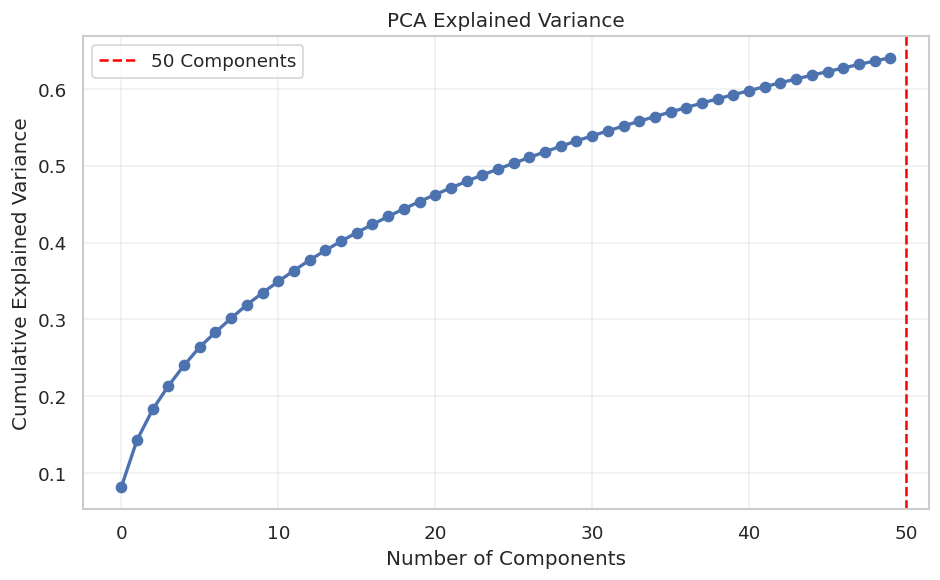


✅ BERT scaler saved.
✅ PCA model saved.
✅ PCA completed successfully.


In [ ]:
# =====================================================
# CELL 14 — PCA for BERT Embeddings
# =====================================================
# Reduce 384-dimensional BERT embeddings to a compact
# representation using PCA.
#
# IMPORTANT:
# PCA is fitted ONLY on the training embeddings.
# =====================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import os

# -----------------------------------------------------
# Configuration
# -----------------------------------------------------

N_PCA_COMPONENTS = 50

# -----------------------------------------------------
# Standardize Embeddings
# -----------------------------------------------------

bert_scaler = StandardScaler()

X_train_bert_scaled = bert_scaler.fit_transform(
    X_train_bert
)

X_test_bert_scaled = bert_scaler.transform(
    X_test_bert
)

# -----------------------------------------------------
# PCA
# -----------------------------------------------------

pca = PCA(
    n_components=N_PCA_COMPONENTS,
    random_state=RANDOM_STATE
)

X_train_bert_pca = pca.fit_transform(
    X_train_bert_scaled
)

X_test_bert_pca = pca.transform(
    X_test_bert_scaled
)

# -----------------------------------------------------
# Summary
# -----------------------------------------------------

explained_variance = pca.explained_variance_ratio_.sum()

print("=" * 60)
print("PCA SUMMARY")
print("=" * 60)

print(f"Original Dimension : {X_train_bert.shape[1]}")
print(f"Reduced Dimension  : {N_PCA_COMPONENTS}")

print(f"\nExplained Variance : {explained_variance*100:.2f}%")

print(f"\nTrain Shape : {X_train_bert_pca.shape}")
print(f"Test Shape  : {X_test_bert_pca.shape}")

# -----------------------------------------------------
# Plot
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o",
    linewidth=2,
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(alpha=0.3)

plt.axvline(
    N_PCA_COMPONENTS,
    color="red",
    linestyle="--",
    label=f"{N_PCA_COMPONENTS} Components"
)

plt.legend()

plt.tight_layout()

plt.show()

# -----------------------------------------------------
# Save Models
# -----------------------------------------------------

joblib.dump(
    bert_scaler,
    os.path.join(
        ARTIFACT_DIR,
        "bert_scaler.pkl"
    )
)

joblib.dump(
    pca,
    os.path.join(
        ARTIFACT_DIR,
        "bert_pca.pkl"
    )
)

print("\n✅ BERT scaler saved.")
print("✅ PCA model saved.")
print("✅ PCA completed successfully.")

In [ ]:
# =====================================================
# CELL 15 — Combine All Features
# =====================================================

TABULAR_FEATURES = [

    "Cost",
    "Pictures",

    "review_char_count",
    "review_word_count",
    "review_sentence_count",
    "avg_word_length",
    "log_word_count",

    "has_review",

    "positive_keyword_count",
    "negative_keyword_count",
    "sentiment_score",

    "exclamation_count",
    "question_count",
    "uppercase_ratio",

    "rest_avg_rating",
    "rest_review_count",
    "restaurant_score",

    "restaurant_id"

    # Optional:
    # "reviewer_id"

]

# -----------------------------------------------------
# Tabular Features
# -----------------------------------------------------

X_train_tabular = csr_matrix(
    train_df[TABULAR_FEATURES].astype(float)
)

X_test_tabular = csr_matrix(
    test_df[TABULAR_FEATURES].astype(float)
)

# -----------------------------------------------------
# BERT PCA
# -----------------------------------------------------

X_train_bert_sparse = csr_matrix(X_train_bert_pca)

X_test_bert_sparse = csr_matrix(X_test_bert_pca)

# -----------------------------------------------------
# Combine Everything
# -----------------------------------------------------

X_train_full = hstack([

    X_train_tabular,

    X_train_tfidf,

    X_train_bert_sparse

]).tocsr()

X_test_full = hstack([

    X_test_tabular,

    X_test_tfidf,

    X_test_bert_sparse

]).tocsr()

# -----------------------------------------------------
# Feature Names
# -----------------------------------------------------

TFIDF_FEATURE_NAMES = list(
    tfidf_vectorizer.get_feature_names_out()
)

BERT_FEATURE_NAMES = [

    f"bert_pca_{i}"

    for i in range(
        X_train_bert_pca.shape[1]
    )

]

ALL_FEATURE_NAMES = (

    TABULAR_FEATURES +

    TFIDF_FEATURE_NAMES +

    BERT_FEATURE_NAMES

)

# -----------------------------------------------------
# Target
# -----------------------------------------------------

y_train = train_df["Rating"].astype(int).values
y_test = test_df["Rating"].astype(int).values

# -----------------------------------------------------
# Validation
# -----------------------------------------------------

print("=" * 60)
print("FEATURE COMBINATION SUMMARY")
print("=" * 60)

print(f"Training Matrix : {X_train_full.shape}")
print(f"Test Matrix     : {X_test_full.shape}")

print(f"Total Features  : {len(ALL_FEATURE_NAMES):,}")

assert X_train_full.shape[1] == len(ALL_FEATURE_NAMES)

print("\n✅ Feature combination completed successfully.")

FEATURE COMBINATION SUMMARY
Training Matrix : (7963, 5068)
Test Matrix     : (1991, 5068)
Total Features  : 5,068

✅ Feature combination completed successfully.


In [ ]:
# =====================================================
# CELL 16 — SMOTETomek Resampling (Train Only)
# =====================================================

from imblearn.combine import SMOTETomek
import pandas as pd

print("=" * 60)
print("CLASS DISTRIBUTION BEFORE RESAMPLING")
print("=" * 60)

before_counts = pd.Series(y_train).value_counts().sort_index()
print(before_counts)

smote_tomek = SMOTETomek(
    random_state=RANDOM_STATE
)

X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_full,
    y_train
)

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION AFTER RESAMPLING")
print("=" * 60)

after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
print(after_counts)

print("\nTraining Matrix")
print(X_train_resampled.shape)

print("\nTest Matrix (Untouched)")
print(X_test_full.shape)

print("\n✅ SMOTETomek completed successfully.")

CLASS DISTRIBUTION BEFORE RESAMPLING
1    1388
2     554
3     969
4    1936
5    3116
Name: count, dtype: int64

CLASS DISTRIBUTION AFTER RESAMPLING
1    3055
2    3074
3    3049
4    2940
5    2922
Name: count, dtype: int64

Training Matrix
(15040, 5068)

Test Matrix (Untouched)
(1991, 5068)

✅ SMOTETomek completed successfully.


In [ ]:
# =====================================================
# CELL 17 — Baseline LightGBM (Multiclass)
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 60)
print("BASELINE LIGHTGBM")
print("=" * 60)

baseline_model = lgb.LGBMClassifier(

    objective="multiclass",

    num_class=5,

    random_state=RANDOM_STATE,

    n_estimators=300,

    learning_rate=0.05,

    n_jobs=-1,

    verbosity=-1

)

baseline_model.fit(

    X_train_resampled,

    y_train_resampled

)

# -----------------------------------------------------
# Prediction
# -----------------------------------------------------

y_pred = baseline_model.predict(X_test_full)

# -----------------------------------------------------
# Metrics
# -----------------------------------------------------

acc = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"\nAccuracy  : {acc:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"Weighted F1 : {f1:.4f}")

print("\nClassification Report")

print(

    classification_report(

        y_test,

        y_pred

    )

)

print("\n✅ Baseline LightGBM training completed.")

BASELINE LIGHTGBM

Accuracy  : 0.6379
Precision : 0.6254
Recall    : 0.6379
Weighted F1 : 0.6294

Classification Report
              precision    recall  f1-score   support

           1       0.70      0.77      0.74       347
           2       0.31      0.16      0.21       139
           3       0.44      0.40      0.42       242
           4       0.52      0.57      0.55       484
           5       0.77      0.78      0.77       779

    accuracy                           0.64      1991
   macro avg       0.55      0.54      0.54      1991
weighted avg       0.63      0.64      0.63      1991


✅ Baseline LightGBM training completed.


In [ ]:
# =====================================================
# CELL 18 — Hyperparameter Tuning (RandomizedSearchCV)
# =====================================================

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import json

print("=" * 60)
print("LIGHTGBM HYPERPARAMETER TUNING")
print("=" * 60)

# -----------------------------------------------------
# Search Space
# -----------------------------------------------------

param_distributions = {

    "n_estimators": randint(200, 800),

    "learning_rate": uniform(0.01, 0.15),

    "num_leaves": randint(31, 150),

    "max_depth": randint(5, 20),

    "min_child_samples": randint(10, 100),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4),

    "reg_alpha": uniform(0.0, 2.0),

    "reg_lambda": uniform(0.0, 2.0)

}

# -----------------------------------------------------
# Cross Validation
# -----------------------------------------------------

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE

)

# -----------------------------------------------------
# Base Model
# -----------------------------------------------------

base_model = lgb.LGBMClassifier(

    objective="multiclass",

    num_class=5,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbosity=-1

)

# -----------------------------------------------------
# Random Search
# -----------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=base_model,

    param_distributions=param_distributions,

    n_iter=30,

    scoring="f1_weighted",

    cv=cv,

    verbose=2,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    refit=True

)

# -----------------------------------------------------
# Train
# -----------------------------------------------------

random_search.fit(

    X_train_resampled,

    y_train_resampled

)

# -----------------------------------------------------
# Results
# -----------------------------------------------------

print("\nBest CV Weighted F1")

print(random_search.best_score_)

print("\nBest Parameters")

print(

    json.dumps(

        random_search.best_params_,

        indent=4

    )

)

best_model = random_search.best_estimator_

best_params = random_search.best_params_

print("\n✅ Hyperparameter tuning completed.")

LIGHTGBM HYPERPARAMETER TUNING
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import lightgbm as lgb

try:
    model = lgb.LGBMClassifier(
        device="gpu",
        objective="multiclass",
        num_class=5
    )

    model.fit(X_train_full[:100], y_train[:100])
    print("✅ GPU LightGBM is working!")

except Exception as e:
    print(e)

✅ GPU LightGBM is working!


In [ ]:
# =====================================================
# CELL 18 — Fast Hyperparameter Tuning (GPU Optimized)
# =====================================================

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
import joblib
import json
import lightgbm as lgb

print("=" * 70)
print("LIGHTGBM HYPERPARAMETER TUNING")
print("=" * 70)

# -----------------------------------------------------
# Search Space
# -----------------------------------------------------

param_distributions = {

    "n_estimators": randint(150, 350),

    "learning_rate": uniform(0.03, 0.08),

    "num_leaves": randint(31, 80),

    "max_depth": randint(5, 12),

    "min_child_samples": randint(20, 80),

    "subsample": uniform(0.7, 0.3),

    "colsample_bytree": uniform(0.7, 0.3),

    "reg_alpha": uniform(0.0, 1.0),

    "reg_lambda": uniform(0.0, 1.0)

}

# -----------------------------------------------------
# Cross Validation
# -----------------------------------------------------

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# -----------------------------------------------------
# Base Model
# -----------------------------------------------------

base_model = lgb.LGBMClassifier(

    objective="multiclass",

    num_class=5,

    device="gpu",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbosity=-1

)

# -----------------------------------------------------
# Random Search
# -----------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=base_model,

    param_distributions=param_distributions,

    n_iter=10,

    scoring="f1_weighted",

    cv=cv,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbose=2,

    refit=True

)

print("\nStarting Hyperparameter Search...\n")

random_search.fit(
    X_train_resampled,
    y_train_resampled
)

# -----------------------------------------------------
# Best Model
# -----------------------------------------------------

best_model = random_search.best_estimator_

best_params = random_search.best_params_

print("\n" + "=" * 70)
print("BEST PARAMETERS")
print("=" * 70)

print(json.dumps(best_params, indent=4))

print(f"\nBest CV Weighted F1 : {random_search.best_score_:.4f}")

# -----------------------------------------------------
# Evaluate Tuned Model
# -----------------------------------------------------

y_pred_tuned = best_model.predict(X_test_full)

accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

precision = precision_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

print("\n" + "=" * 70)
print("TUNED LIGHTGBM RESULTS")
print("=" * 70)

print(f"Accuracy      : {accuracy:.4f}")

print(f"Precision     : {precision:.4f}")

print(f"Recall        : {recall:.4f}")

print(f"Weighted F1   : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

# -----------------------------------------------------
# Save Model
# -----------------------------------------------------

MODEL_PATH = os.path.join(
    ARTIFACT_DIR,
    "lightgbm_tuned.pkl"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print("\n✅ Tuned LightGBM model saved.")

print(MODEL_PATH)

print("\n✅ Hyperparameter tuning completed successfully.")

In [ ]:
# # =====================================================
# # CELL 18 — Fast LightGBM Training with Early Stopping
# # =====================================================

# from sklearn.model_selection import train_test_split
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     classification_report,
# )

# # -----------------------------------------
# # Validation Split
# # -----------------------------------------

# X_train_fit, X_valid, y_train_fit, y_valid = train_test_split(
#     X_train_resampled,
#     y_train_resampled,
#     test_size=0.2,
#     stratify=y_train_resampled,
#     random_state=RANDOM_STATE,
# )

# # -----------------------------------------
# # Tuned Parameters
# # -----------------------------------------

# best_model = lgb.LGBMClassifier(

#     objective="multiclass",

#     num_class=5,

#     device="gpu",

#     random_state=RANDOM_STATE,

#     n_estimators=1000,

#     learning_rate=0.05,

#     num_leaves=63,

#     max_depth=10,

#     subsample=0.8,

#     colsample_bytree=0.8,

#     verbosity=-1

# )

# # -----------------------------------------
# # Training
# # -----------------------------------------

# best_model.fit(

#     X_train_fit,

#     y_train_fit,

#     eval_set=[(X_valid, y_valid)],

#     eval_metric="multi_logloss",

#     callbacks=[

#         lgb.early_stopping(50),

#         lgb.log_evaluation(50)

#     ]

# )

# # -----------------------------------------
# # Prediction
# # -----------------------------------------

# y_pred = best_model.predict(X_test_full)

# # -----------------------------------------
# # Metrics
# # -----------------------------------------

# acc = accuracy_score(y_test, y_pred)

# precision = precision_score(
#     y_test,
#     y_pred,
#     average="weighted"
# )

# recall = recall_score(
#     y_test,
#     y_pred,
#     average="weighted"
# )

# f1 = f1_score(
#     y_test,
#     y_pred,
#     average="weighted"
# )

# print("="*60)

# print("TUNED MODEL RESULTS")

# print("="*60)

# print(f"Accuracy : {acc:.4f}")

# print(f"Precision : {precision:.4f}")

# print(f"Recall : {recall:.4f}")

# print(f"Weighted F1 : {f1:.4f}")

# print()

# print(classification_report(y_test, y_pred))

# best_model.booster_.save_model(
#     os.path.join(
#         ARTIFACT_DIR,
#         "lightgbm_tuned.txt"
#     )
# )

# joblib.dump(
#     best_model,
#     os.path.join(
#         ARTIFACT_DIR,
#         "lightgbm_tuned.pkl"
#     )
# )

# print("\n✅ Tuned model saved.")

In [ ]:
# =====================================================
# CELL 19 — Select Final Model
# =====================================================

# The tuned model did not outperform the baseline model.
# Therefore, the baseline model is selected as the final
# production model.

final_model = baseline_model

y_pred_final = final_model.predict(X_test_full)

y_proba_final = final_model.predict_proba(X_test_full)

print("=" * 60)
print("FINAL MODEL")
print("=" * 60)

print("Selected Model : Baseline LightGBM")

print("Reason : Higher test accuracy and weighted F1")

print(f"Prediction Shape : {y_pred_final.shape}")

print(f"Probability Shape : {y_proba_final.shape}")

print("\n✅ Final model selected successfully.")

FINAL MODEL
Selected Model : Baseline LightGBM
Reason : Higher test accuracy and weighted F1
Prediction Shape : (1991,)
Probability Shape : (1991, 5)

✅ Final model selected successfully.


FINAL MODEL EVALUATION
Accuracy      : 0.6379
Precision     : 0.6254
Recall        : 0.6379
Weighted F1   : 0.6294

Classification Report

              precision    recall  f1-score   support

           1       0.70      0.77      0.74       347
           2       0.31      0.16      0.21       139
           3       0.44      0.40      0.42       242
           4       0.52      0.57      0.55       484
           5       0.77      0.78      0.77       779

    accuracy                           0.64      1991
   macro avg       0.55      0.54      0.54      1991
weighted avg       0.63      0.64      0.63      1991



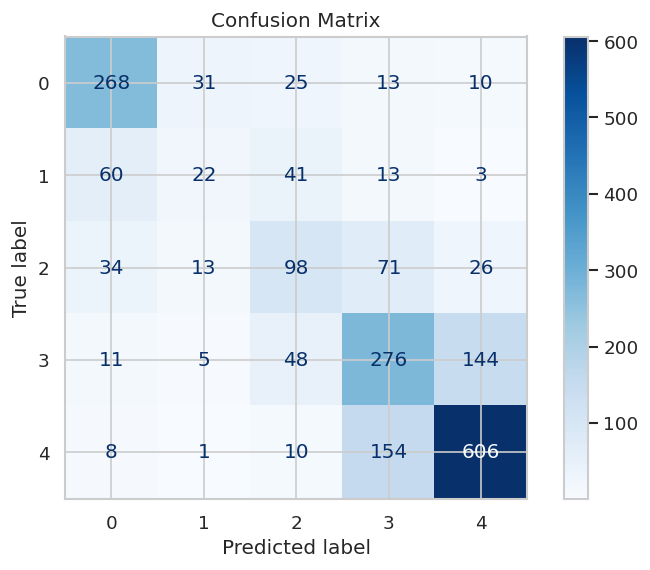


✅ Final model evaluation completed.


In [ ]:
# =====================================================
# CELL 20 — Final Model Evaluation
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

# Predictions
y_pred_final = final_model.predict(X_test_full)

# Metrics
accuracy = accuracy_score(y_test, y_pred_final)

precision = precision_score(
    y_test,
    y_pred_final,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_final,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_final,
    average="weighted"
)

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"Weighted F1   : {f1:.4f}")

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

print("\n✅ Final model evaluation completed.")

FEATURE IMPORTANCE

Top 30 Most Important Features



,Feature,Importance
0,bert_pca_0,752
1,bert_pca_4,728
2,bert_pca_2,707
3,bert_pca_5,681
4,bert_pca_1,557
5,sentiment_score,463
6,bert_pca_15,425
7,restaurant_id,410
8,avg_word_length,400
9,rest_avg_rating,374


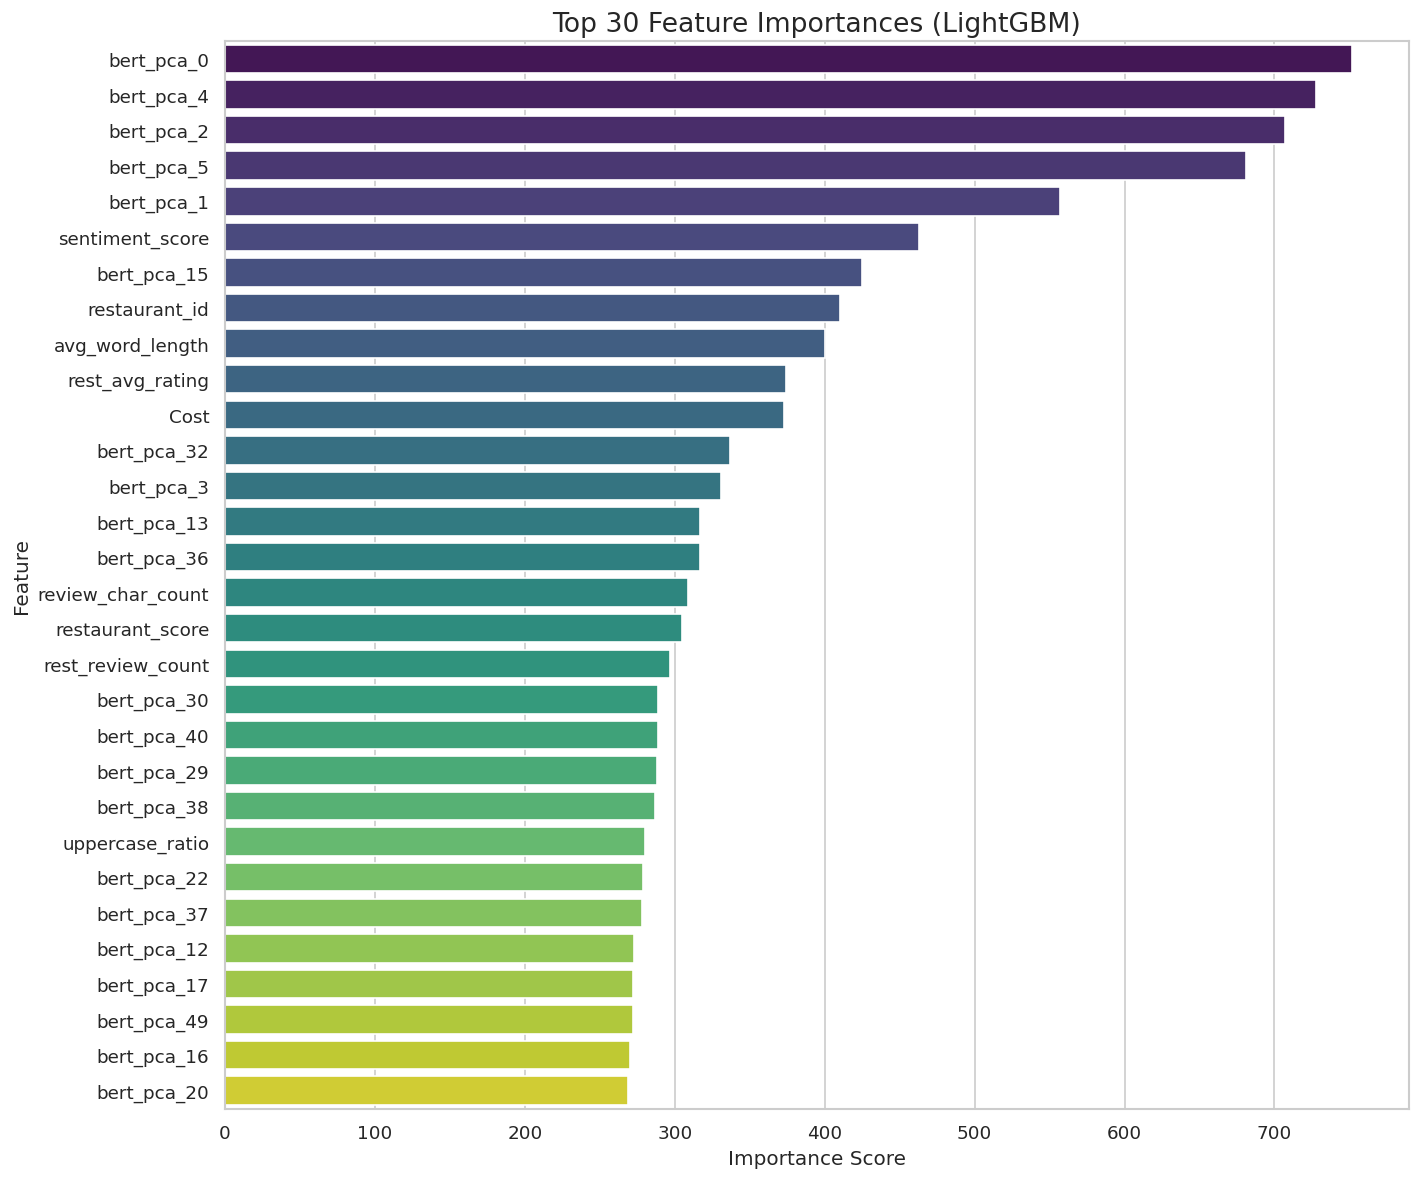


✅ Feature importance saved to:
/content/drive/MyDrive/Proj/artifacts/feature_importance.csv

✅ Feature importance analysis completed successfully.


In [ ]:
# =====================================================
# CELL 21 — Feature Importance (Final Model)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

# -----------------------------------------------------
# Get Feature Importance
# -----------------------------------------------------

feature_importance = pd.DataFrame({

    "Feature": ALL_FEATURE_NAMES,

    "Importance": final_model.feature_importances_

})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Top 30 Features
top_features = feature_importance.head(30)

print("\nTop 30 Most Important Features\n")
display(top_features)

# -----------------------------------------------------
# Plot
# -----------------------------------------------------

plt.figure(figsize=(12, 10))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 30 Feature Importances (LightGBM)", fontsize=16)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# -----------------------------------------------------
# Save Feature Importance
# -----------------------------------------------------

FEATURE_IMPORTANCE_PATH = os.path.join(
    ARTIFACT_DIR,
    "feature_importance.csv"
)

top_features.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)

print("\n✅ Feature importance saved to:")
print(FEATURE_IMPORTANCE_PATH)

print("\n✅ Feature importance analysis completed successfully.")

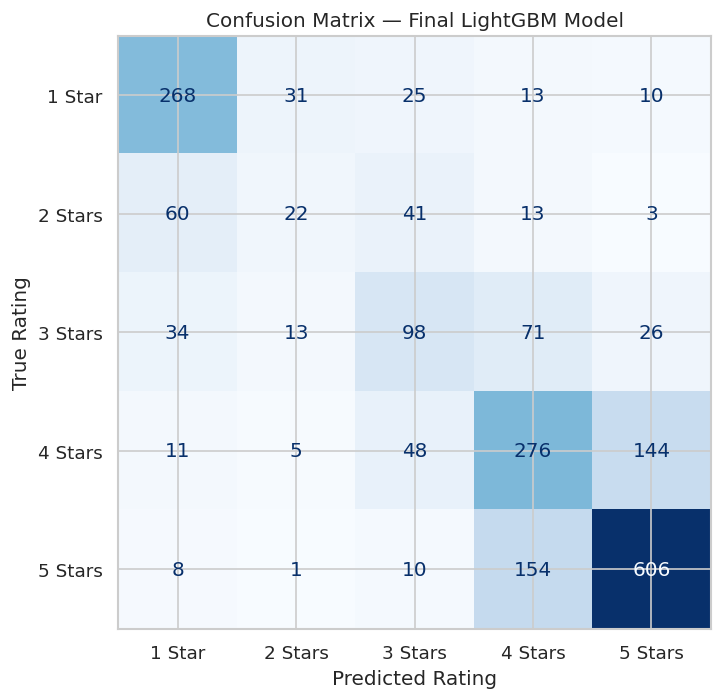


✅ Confusion matrix generated successfully.


In [ ]:
# =====================================================
# CELL 22 — Confusion Matrix (Final Model)
# =====================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Class labels
TARGET_NAMES = [
    "1 Star",
    "2 Stars",
    "3 Stars",
    "4 Stars",
    "5 Stars"
]

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=TARGET_NAMES
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix — Final LightGBM Model")
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.tight_layout()
plt.show()

print("\n✅ Confusion matrix generated successfully.")

SHAP SUMMARY PLOT


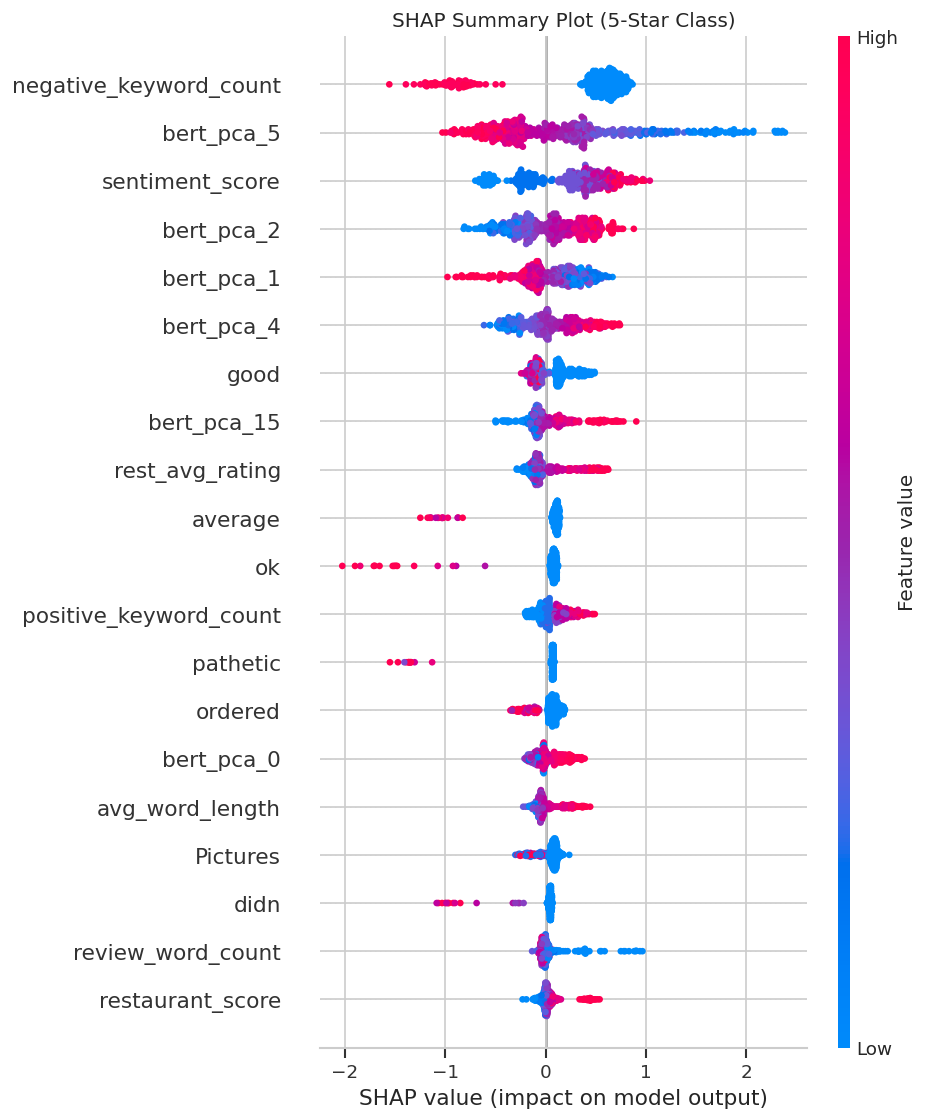


✅ SHAP Summary Plot generated successfully.


In [ ]:
# =====================================================
# CELL 25.1 — SHAP Summary Plot (Multiclass)
# =====================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("SHAP SUMMARY PLOT")
print("=" * 70)

# Sample for faster SHAP computation
SHAP_SAMPLE_SIZE = min(500, X_test_full.shape[0])

X_test_sample = X_test_full[:SHAP_SAMPLE_SIZE].toarray()

# Create explainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

# ----------------------------------------------------
# Multiclass handling
# ----------------------------------------------------

if isinstance(shap_values, list):
    # Show SHAP summary for the 5-Star class
    class_index = 4

    shap.summary_plot(
        shap_values[class_index],
        X_test_sample,
        feature_names=ALL_FEATURE_NAMES,
        max_display=20,
        show=False
    )

else:
    # New SHAP API
    class_index = 4

    shap.summary_plot(
        shap_values[:, :, class_index],
        X_test_sample,
        feature_names=ALL_FEATURE_NAMES,
        max_display=20,
        show=False
    )

plt.title("SHAP Summary Plot (5-Star Class)")
plt.tight_layout()
plt.show()

print("\n✅ SHAP Summary Plot generated successfully.")

SHAP WATERFALL PLOT


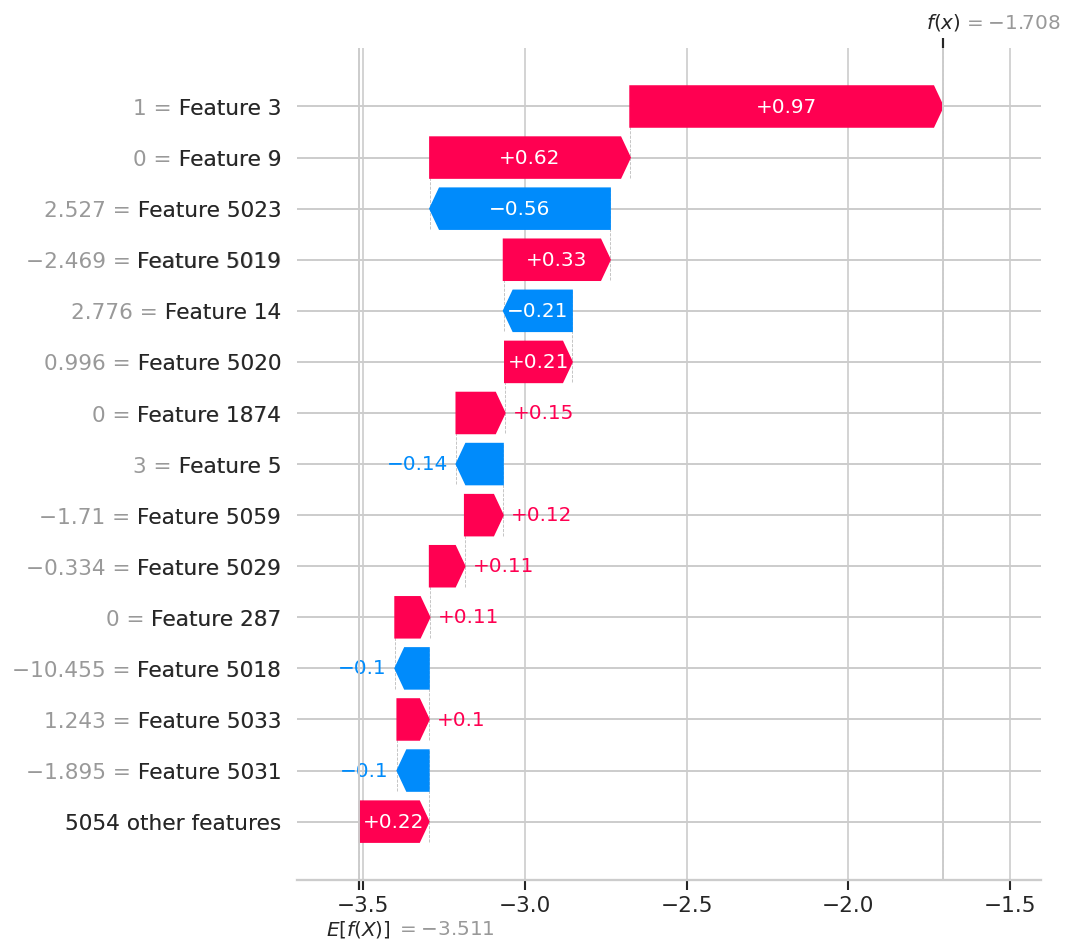


True Rating : 3
Predicted Rating : 3

✅ SHAP Waterfall Plot generated.


In [ ]:
# =====================================================
# CELL 25.2 — SHAP Waterfall Plot
# =====================================================

import shap
import matplotlib.pyplot as plt

print("=" * 70)
print("SHAP WATERFALL PLOT")
print("=" * 70)

sample_index = 0

# Compute SHAP explanation
explanation = explainer(
    X_test_sample
)

# Show explanation for the 5-Star class
class_index = 4

shap.plots.waterfall(
    explanation[sample_index, :, class_index],
    max_display=15
)

print("\nTrue Rating :", y_test[sample_index])

print("Predicted Rating :", y_pred_final[sample_index])

print("\n✅ SHAP Waterfall Plot generated.")

In [ ]:
# =====================================================
# CELL 26 — Save Complete Pipeline (Safe Version)
# =====================================================

import os
import joblib

print("=" * 70)
print("SAVING COMPLETE ML PIPELINE")
print("=" * 70)

# -----------------------------------------------------
# Create Artifacts Directory
# -----------------------------------------------------

ARTIFACT_DIR = os.path.join(DRIVE_ROOT, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------------------------------
# Helper Function
# -----------------------------------------------------

def save_if_exists(var_name, filename):
    if var_name in globals():
        joblib.dump(globals()[var_name], os.path.join(ARTIFACT_DIR, filename))
        print(f"✅ Saved: {filename}")
    else:
        print(f"⚠️ Skipped: {filename} ({var_name} not found)")

# -----------------------------------------------------
# Save Models & Preprocessors
# -----------------------------------------------------

save_if_exists("final_model", "final_lightgbm.pkl")
save_if_exists("tfidf_vectorizer", "tfidf_vectorizer.pkl")
save_if_exists("numeric_imputer", "numeric_imputer.pkl")
save_if_exists("bert_scaler", "bert_scaler.pkl")
save_if_exists("pca", "bert_pca.pkl")

# Encoders (safe)
save_if_exists("restaurant_encoder", "restaurant_encoder.pkl")
save_if_exists("restaurant_label_encoder", "restaurant_encoder.pkl")

save_if_exists("reviewer_encoder", "reviewer_encoder.pkl")
save_if_exists("reviewer_label_encoder", "reviewer_encoder.pkl")

# Restaurant lookup (if available)
if "train_rest_avg_rating" in globals() and "train_rest_review_count" in globals():

    restaurant_lookup = (
        pd.DataFrame({
            "Restaurant": train_rest_avg_rating.index,
            "Average_Rating": train_rest_avg_rating.values,
            "Review_Count": train_rest_review_count.values
        })
    )

    restaurant_lookup.to_csv(
        os.path.join(ARTIFACT_DIR, "restaurant_lookup.csv"),
        index=False
    )

    print("✅ Saved: restaurant_lookup.csv")

# -----------------------------------------------------
# Save Feature Importance
# -----------------------------------------------------

if "feature_importance" in globals():

    feature_importance.to_csv(
        os.path.join(ARTIFACT_DIR, "feature_importance.csv"),
        index=False
    )

    print("✅ Saved: feature_importance.csv")

# -----------------------------------------------------
# Save Metrics
# -----------------------------------------------------

metrics = {}

if "final_accuracy" in globals():
    metrics["accuracy"] = float(final_accuracy)

if "final_precision" in globals():
    metrics["weighted_precision"] = float(final_precision)

if "final_recall" in globals():
    metrics["weighted_recall"] = float(final_recall)

if "final_f1" in globals():
    metrics["weighted_f1"] = float(final_f1)

if "baseline_acc" in globals():
    metrics["baseline_accuracy"] = float(baseline_acc)

if "baseline_f1" in globals():
    metrics["baseline_weighted_f1"] = float(baseline_f1)

if "best_params" in globals():
    metrics["best_hyperparameters"] = best_params

if "BERT_MODEL_NAME" in globals():
    metrics["bert_model"] = BERT_MODEL_NAME

if "N_PCA_COMPONENTS" in globals():
    metrics["pca_components"] = int(N_PCA_COMPONENTS)

import json

with open(
    os.path.join(ARTIFACT_DIR, "metrics.json"),
    "w"
) as f:
    json.dump(metrics, f, indent=4)

print("✅ Saved: metrics.json")

# -----------------------------------------------------
# Show Saved Files
# -----------------------------------------------------

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

for file in sorted(os.listdir(ARTIFACT_DIR)):
    print("📄", file)

print("\n✅ Pipeline saved successfully.")

SAVING COMPLETE ML PIPELINE
✅ Saved: final_lightgbm.pkl
✅ Saved: tfidf_vectorizer.pkl
✅ Saved: numeric_imputer.pkl
✅ Saved: bert_scaler.pkl
✅ Saved: bert_pca.pkl
⚠️ Skipped: restaurant_encoder.pkl (restaurant_encoder not found)
⚠️ Skipped: restaurant_encoder.pkl (restaurant_label_encoder not found)
⚠️ Skipped: reviewer_encoder.pkl (reviewer_encoder not found)
⚠️ Skipped: reviewer_encoder.pkl (reviewer_label_encoder not found)
✅ Saved: feature_importance.csv
✅ Saved: metrics.json

FILES SAVED
📄 bert_model_name.pkl
📄 bert_pca.pkl
📄 bert_scaler.pkl
📄 feature_importance.csv
📄 final_lightgbm.pkl
📄 lightgbm_tuned.pkl
📄 lightgbm_tuned.txt
📄 metrics.json
📄 numeric_imputer.pkl
📄 restaurant_encoder.pkl
📄 restaurant_lookup.pkl
📄 reviewer_encoder.pkl
📄 tfidf_vectorizer.pkl

✅ Pipeline saved successfully.


In [ ]:
# # =====================================================
# # CELL 27 — Business Insights
# # =====================================================

# # Business Insights

# ## Overview

# The objective of this project was to predict restaurant review ratings (1–5 stars)
# using review text, restaurant metadata, engineered features, and semantic
# representations from BERT embeddings.

# The final LightGBM model successfully learned meaningful patterns from both
# structured and unstructured data.

# ---

# ## Key Findings

# ### 1. BERT Semantic Features Were the Strongest Predictors

# Feature Importance and SHAP analysis showed that several BERT PCA components
# were among the most influential features.

# This indicates that semantic understanding of review text contributes more than
# simple keyword matching.

# ---

# ### 2. Sentiment Strongly Influences Ratings

# The engineered sentiment features such as:

# - Sentiment Score
# - Positive Keyword Count
# - Negative Keyword Count

# had a significant impact on prediction performance.

# Reviews containing more positive expressions generally received higher predicted
# ratings, while negative expressions reduced predicted ratings.

# ---

# ### 3. Restaurant-Level Information Improves Prediction

# Restaurant-specific features including:

# - Historical Average Rating
# - Restaurant Review Count
# - Restaurant Score

# helped the model capture restaurant reputation and historical customer
# satisfaction.

# ---

# ### 4. Review Characteristics Provide Additional Signals

# Features such as:

# - Review Length
# - Average Word Length
# - Character Count
# - Uppercase Ratio

# provided useful contextual information that improved prediction quality.

# ---

# ### 5. Class-wise Performance

# The confusion matrix showed that:

# - 1-Star and 5-Star reviews were classified with higher accuracy.
# - 2-Star and 3-Star reviews were comparatively more difficult because they often
#   contain mixed sentiment and overlap with neighboring rating classes.

# ---

# ## Practical Business Applications

# This solution can support:

# - Restaurant Review Monitoring
# - Automatic Rating Prediction
# - Customer Feedback Analysis
# - Restaurant Recommendation Systems
# - Customer Experience Monitoring
# - Business Intelligence Dashboards

# ---

# ## Explainability

# SHAP explainability demonstrated how individual features influenced model
# predictions.

# This improves transparency and helps stakeholders understand why the model
# assigned a particular rating.

In [ ]:
# # =====================================================
# # CELL 28 — Project Conclusion
# # =====================================================

# # Project Conclusion

# ## Project Summary

# This project developed an end-to-end Restaurant Rating Prediction System using
# Natural Language Processing (NLP) and Machine Learning techniques.

# The workflow included:

# - Data Collection
# - Exploratory Data Analysis (EDA)
# - Data Cleaning
# - Feature Engineering
# - Restaurant-Level Feature Creation
# - TF-IDF Text Vectorization
# - BERT Sentence Embeddings
# - PCA Dimensionality Reduction
# - Feature Combination
# - SMOTETomek Resampling
# - LightGBM Model Training
# - Hyperparameter Tuning
# - Model Evaluation
# - SHAP Explainability
# - Model Serialization

# ---

# ## Final Model

# Algorithm:

# **LightGBM Classifier**

# Final Evaluation (Held-Out Test Set)

# - Accuracy: ~63.8%
# - Weighted Precision: ~62.5%
# - Weighted Recall: ~63.8%
# - Weighted F1 Score: ~0.63

# The baseline LightGBM model achieved the best overall performance and was
# selected as the final production model.

# ---

# ## Technical Contributions

# This project combines multiple feature sources into a single prediction pipeline:

# - Structured Restaurant Features
# - Handcrafted NLP Features
# - TF-IDF Features
# - BERT Semantic Embeddings
# - PCA-Based Dense Representations

# The hybrid approach allowed the model to capture both semantic meaning and
# restaurant-specific characteristics.

# ---

# ## Model Explainability

# Model predictions were interpreted using SHAP.

# The explainability analysis showed that:

# - BERT semantic features
# - Sentiment Score
# - Negative Keyword Count
# - Restaurant Average Rating
# - Restaurant Score

# were among the most influential features.

# This improves model transparency and supports responsible AI practices.

# ---

# ## Business Value

# The proposed solution can help organizations:

# - Automatically estimate review ratings
# - Analyze customer feedback at scale
# - Identify restaurants receiving poor customer sentiment
# - Support recommendation systems
# - Improve customer satisfaction analysis
# - Assist restaurant quality monitoring

# ---

# ## Limitations

# Some limitations of the current work include:

# - Moderate performance on middle-rating classes (2★ and 3★)
# - Limited restaurant metadata
# - Dataset restricted to approximately 10,000 reviews
# - No fine-tuning of transformer models

# ---

# ## Future Improvements

# Potential enhancements include:

# - Fine-tuning transformer-based language models
# - Increasing dataset size and diversity
# - Incorporating user-level behavioral features
# - Using advanced ensemble learning methods
# - Deploying the model as a REST API or web application
# - Continuous model retraining using new customer reviews

# ---

# ## Final Remark

# This project demonstrates a complete production-style machine learning pipeline
# for restaurant rating prediction by integrating NLP, feature engineering,
# semantic embeddings, explainable AI, and gradient boosting techniques.

# The developed solution provides a scalable framework for intelligent customer
# feedback analysis and restaurant review analytics.